In [1]:
!pip install wordcloud

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from wordcloud import WordCloud

In [8]:
import pandas as pd

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df = pd.read_csv(url, sep='\t', names=['label', 'message'])

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [11]:
import re

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'\d+', '', texto)
    texto = re.sub(r'[^\w\s]', '', texto)
    return texto

df['message'] = df['message'].apply(limpiar_texto)

df.head()

,label,message
0,0,go until jurong point crazy available only in ...
1,0,ok lar joking wif u oni
2,1,free entry in a wkly comp to win fa cup final...
3,0,u dun say so early hor u c already then say
4,0,nah i dont think he goes to usf he lives aroun...


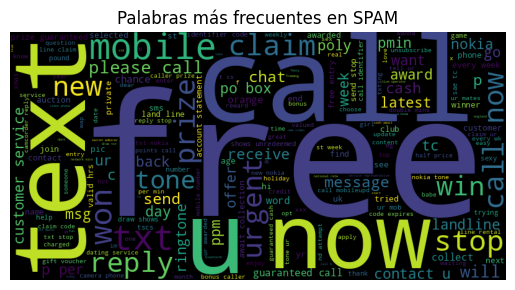

In [13]:
spam_text = " ".join(df[df['label']==1]['message'])

wordcloud = WordCloud(width=800, height=400).generate(spam_text)

plt.figure()
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Palabras más frecuentes en SPAM")
plt.show()

In [14]:
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    max_features=5000
)

X = tfidf.fit_transform(df['message'])
y = df['label']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9614349775784753
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.71      0.83       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.90      1115
weighted avg       0.96      0.96      0.96      1115



In [17]:
feature_names = tfidf.get_feature_names_out()
coef = model.coef_[0]

top_spam = np.argsort(coef)[-15:]
top_ham = np.argsort(coef)[:15]

print("Palabras más asociadas a SPAM:")
print([feature_names[i] for i in top_spam])

print("\nPalabras más asociadas a NO SPAM:")
print([feature_names[i] for i in top_ham])

Palabras más asociadas a SPAM:
['urgent', 'nokia', 'ringtone', 'service', 'win', 'new', 'prize', 'won', 'reply', 'stop', 'text', 'free', 'mobile', 'claim', 'txt']

Palabras más asociadas a NO SPAM:
['im', 'ltgt', 'ok', 'ill', 'come', 'home', 'later', 'da', 'got', 'lor', 'sorry', 'oh', 'going', 'dont', 'thats']


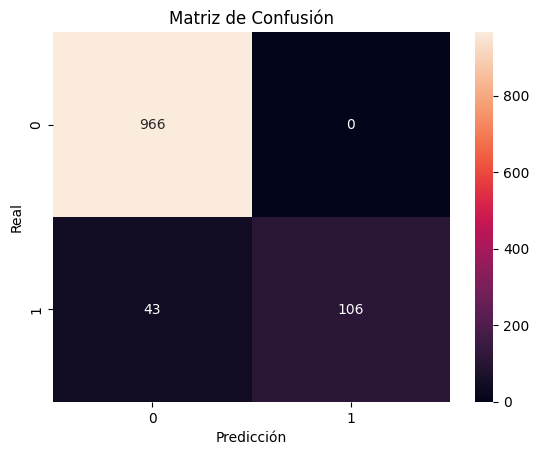

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

In [19]:
mensaje = ["Congratulations! You have won a free prize"]

mensaje_limpio = limpiar_texto(mensaje[0])
mensaje_vector = tfidf.transform([mensaje_limpio])

prediccion = model.predict(mensaje_vector)

if prediccion[0] == 1:
    print("Es SPAM")
else:
    print("No es spam")

Es SPAM


In [20]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Accuracy Naive Bayes:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Accuracy Naive Bayes: 0.9766816143497757
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       1.00      0.83      0.90       149

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [21]:
print("Regresión Logística:", accuracy_score(y_test, y_pred))
print("Naive Bayes:", accuracy_score(y_test, y_pred_nb))

Regresión Logística: 0.9614349775784753
Naive Bayes: 0.9766816143497757


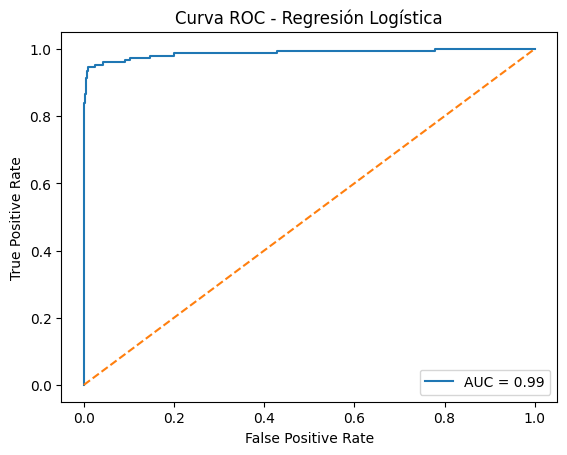

In [22]:
from sklearn.metrics import roc_curve, auc

# Probabilidades del modelo
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión Logística")
plt.legend()
plt.show()

In [23]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5)

print("Accuracy por fold:", cv_scores)
print("Accuracy promedio:", cv_scores.mean())

Accuracy por fold: [0.96233184 0.95156951 0.9524237  0.9524237  0.96229803]
Accuracy promedio: 0.9562093534389063


In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}

grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)

Mejores parámetros: {'C': 10, 'solver': 'liblinear'}


In [25]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Accuracy Optimizado:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Accuracy Optimizado: 0.9856502242152466
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.89      0.94       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115



In [26]:
model_bal = LogisticRegression(class_weight='balanced')
model_bal.fit(X_train, y_train)

y_pred_bal = model_bal.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_bal))
print(classification_report(y_test, y_pred_bal))

Accuracy: 0.9847533632286996
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.95      0.93      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.97      1115
weighted avg       0.98      0.98      0.98      1115



In [27]:
threshold = 0.5

In [28]:
y_probs = model_bal.predict_proba(X_test)[:,1]

In [29]:
import numpy as np

threshold = 0.4

y_pred_custom = (y_probs >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

Accuracy: 0.9775784753363229
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       966
           1       0.89      0.95      0.92       149

    accuracy                           0.98      1115
   macro avg       0.94      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115



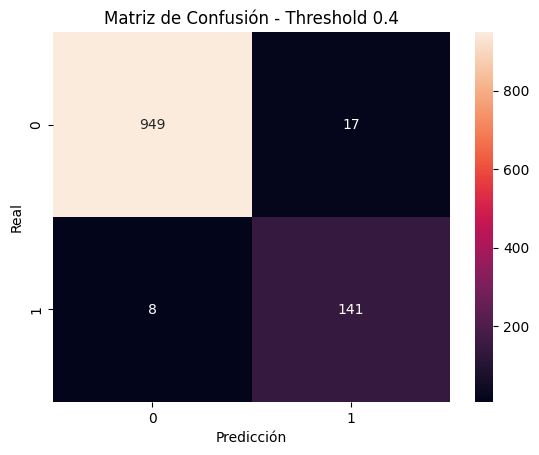

In [30]:
cm = confusion_matrix(y_test, y_pred_custom)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Threshold 0.4")
plt.show()